# 🤖 Stance Detection — Fine-tune RoBERTa on GPU

**Input:** `stance_dataset_labeled.csv` (from previous notebook)  
**Output:** Trained model saved locally + evaluation report

Pipeline:
1. Load & prepare data
2. Tokenize with RoBERTa tokenizer
3. Fine-tune RoBERTa-base
4. Evaluate (Accuracy, F1, Confusion Matrix)
5. Save model for inference

## 🔧 Step 1: Install & Import

In [1]:
!pip install transformers datasets scikit-learn pandas matplotlib seaborn torch accelerate -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from torch.utils.data import Dataset, DataLoader
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
import warnings
warnings.filterwarnings('ignore')

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

C:\Users\SUMIT YADAV\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Using device: cpu


## 📂 Step 2: Load Dataset

In [3]:
df = pd.read_csv('stance_dataset_labeled.csv')

print(f'Total rows: {len(df):,}')
print(f'Columns:    {df.columns.tolist()}')
print()
print('Stance distribution:')
print(df['stance_label'].value_counts())
df.head()

Total rows: 4,213
Columns:    ['clean_text', 'stance_label', 'topic', 'source']

Stance distribution:
stance_label
against    2410
favor      1803
Name: count, dtype: int64


,clean_text,stance_label,topic,source
0,Why Is The Pope Upset? via @user #UnzippedTru...,against,climate,tweeteval
1,We support Australia's Climate Roundtable whic...,favor,climate,tweeteval
2,It's nights like this when I'm not so fond of ...,against,climate,tweeteval
3,#Republican party will go down in history book...,against,climate,tweeteval
4,RT @user @user We need degrowth - stop destroy...,favor,climate,tweeteval


In [4]:
# Map labels to integers
LABEL2ID = {'against': 0, 'neutral': 1, 'favor': 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = len(LABEL2ID)

# Keep only known labels
df = df[df['stance_label'].isin(LABEL2ID.keys())].copy()
df['label_id'] = df['stance_label'].map(LABEL2ID)
df = df.dropna(subset=['clean_text', 'label_id']).reset_index(drop=True)

print(f'Clean dataset size: {len(df):,}')
print('Label mapping:', LABEL2ID)

Clean dataset size: 4,213
Label mapping: {'against': 0, 'neutral': 1, 'favor': 2}


## ✂️ Step 3: Train / Validation / Test Split

Train : 2,949 rows
Val   : 632 rows
Test  : 632 rows


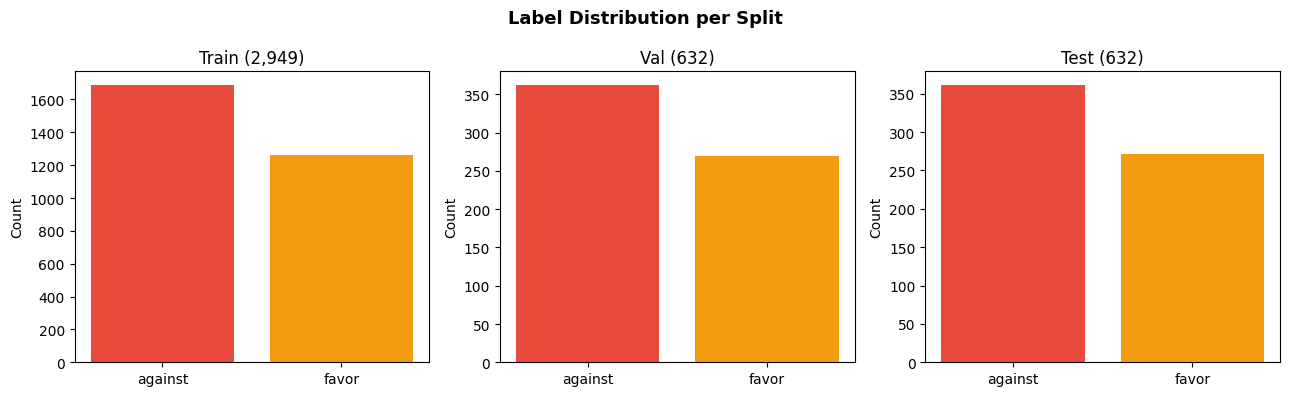

In [5]:
# 70% train | 15% val | 15% test — stratified by label
df_train, df_temp = train_test_split(df, test_size=0.30, stratify=df['label_id'], random_state=42)
df_val,   df_test = train_test_split(df_temp, test_size=0.50, stratify=df_temp['label_id'], random_state=42)

print(f'Train : {len(df_train):,} rows')
print(f'Val   : {len(df_val):,} rows')
print(f'Test  : {len(df_test):,} rows')

# Visualize split
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (split_df, name) in zip(axes, [(df_train,'Train'), (df_val,'Val'), (df_test,'Test')]):
    counts = split_df['stance_label'].value_counts()
    ax.bar(counts.index, counts.values, color=['#e74c3c','#f39c12','#2ecc71'])
    ax.set_title(f'{name} ({len(split_df):,})')
    ax.set_ylabel('Count')
plt.suptitle('Label Distribution per Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔤 Step 4: Tokenize with RoBERTa

In [6]:
MODEL_NAME = 'roberta-base'
MAX_LEN    = 128

print(f'Loading tokenizer: {MODEL_NAME}...')
tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)
print('✅ Tokenizer loaded')

Loading tokenizer: roberta-base...


✅ Tokenizer loaded


In [7]:
class StanceDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.tolist()
        self.labels    = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length      = self.max_len,
            padding         = 'max_length',
            truncation      = True,
            return_tensors  = 'pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

BATCH_SIZE = 16

train_dataset = StanceDataset(df_train['clean_text'], df_train['label_id'], tokenizer, MAX_LEN)
val_dataset   = StanceDataset(df_val['clean_text'],   df_val['label_id'],   tokenizer, MAX_LEN)
test_dataset  = StanceDataset(df_test['clean_text'],  df_test['label_id'],  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f'✅ Datasets ready')
print(f'   Train batches : {len(train_loader)}')
print(f'   Val batches   : {len(val_loader)}')
print(f'   Test batches  : {len(test_loader)}')

✅ Datasets ready
   Train batches : 185
   Val batches   : 40
   Test batches  : 40


## 🏋️ Step 5: Load RoBERTa Model

In [8]:
print(f'Loading model: {MODEL_NAME}...')
model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels  = NUM_LABELS,
    id2label    = ID2LABEL,
    label2id    = LABEL2ID
)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Model loaded on {device}')
print(f'   Total parameters    : {total_params/1e6:.1f}M')
print(f'   Trainable parameters: {trainable/1e6:.1f}M')

Loading model: roberta-base...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 9209.31it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded on cpu
   Total parameters    : 124.6M
   Trainable parameters: 124.6M


## ⚙️ Step 6: Optimizer & Scheduler

In [9]:
EPOCHS       = 4
LR           = 2e-5
WARMUP_RATIO = 0.1

optimizer    = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

print(f'Total training steps : {total_steps}')
print(f'Warmup steps         : {warmup_steps}')
print(f'Epochs               : {EPOCHS}')
print(f'Learning rate        : {LR}')

Total training steps : 740
Warmup steps         : 74
Epochs               : 4
Learning rate        : 2e-05


## 🚀 Step 7: Training Loop

In [10]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for i, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        if (i + 1) % 50 == 0:
            print(f'   Batch {i+1}/{len(loader)}  loss={loss.item():.4f}  acc={correct/total:.4f}')

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs     = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds       = outputs.logits.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    f1       = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, accuracy, f1, all_preds, all_labels

print('✅ Training functions defined')

✅ Training functions defined


In [11]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_f1        = 0
best_model_path = 'roberta_stance_best.pt'

print('🚀 Starting training...\n')

for epoch in range(1, EPOCHS + 1):
    print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
    print(f'EPOCH {epoch}/{EPOCHS}')
    print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss, val_acc, val_f1, _, _ = eval_epoch(model, val_loader, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f'\n  Train  → loss: {train_loss:.4f}  acc: {train_acc:.4f}')
    print(f'  Val    → loss: {val_loss:.4f}  acc: {val_acc:.4f}  F1: {val_f1:.4f}')

    # Save best model
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)
        print(f'  💾 Best model saved! (F1: {best_f1:.4f})')
    print()

print(f'\n✅ Training complete! Best Val F1: {best_f1:.4f}')

🚀 Starting training...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EPOCH 1/4
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Batch 50/185  loss=0.6368  acc=0.3912
   Batch 100/185  loss=0.4813  acc=0.5519
   Batch 150/185  loss=0.4741  acc=0.6062

  Train  → loss: 0.6924  acc: 0.6348
  Val    → loss: 0.5921  acc: 0.6994  F1: 0.6975
  💾 Best model saved! (F1: 0.6975)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EPOCH 2/4
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Batch 50/185  loss=0.4824  acc=0.8137
   Batch 100/185  loss=0.5019  acc=0.8087
   Batch 150/185  loss=0.7268  acc=0.8133

  Train  → loss: 0.4303  acc: 0.8142
  Val    → loss: 0.4514  acc: 0.7832  F1: 0.7775
  💾 Best model saved! (F1: 0.7775)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EPOCH 3/4
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Batch 50/185  loss=0.4302  acc=0.8700
   Batch 100/185  loss=0.7241  acc=0.8731
   Batch 150/185  loss=0.1638  acc=0.8758

  Train  → loss: 0.2808  acc: 0.8850
  Val    → loss: 0.5067  acc: 0.7975  F1: 0.7927
  💾 Best model saved! (F1: 0

## 📈 Step 8: Plot Training Curves

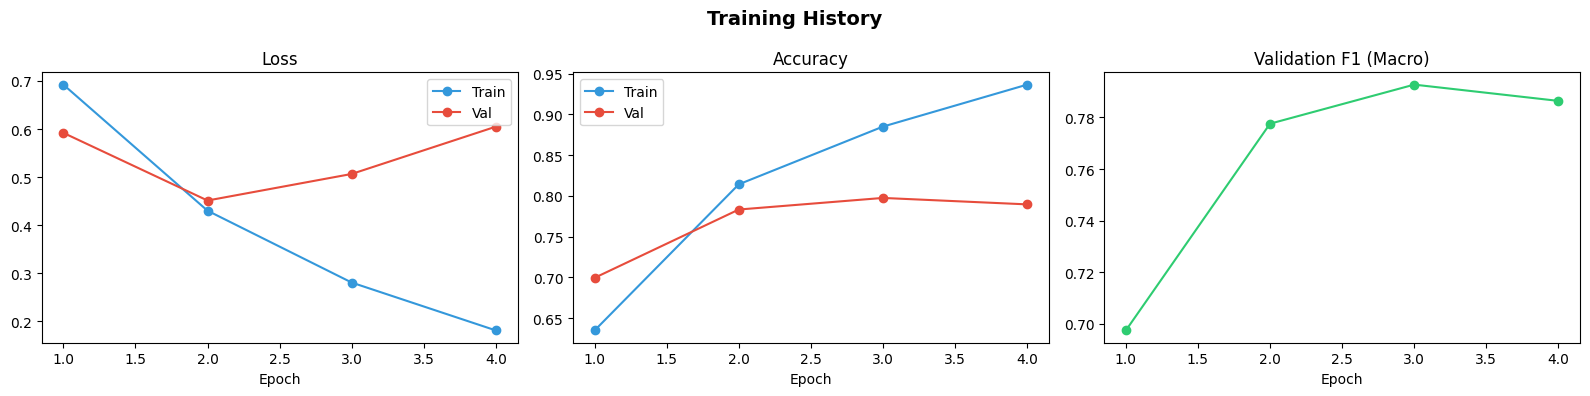

📊 Chart saved: training_curves.png


In [12]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train', color='#3498db')
axes[0].plot(epochs_range, history['val_loss'],   'o-', label='Val',   color='#e74c3c')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], 'o-', label='Train', color='#3498db')
axes[1].plot(epochs_range, history['val_acc'],   'o-', label='Val',   color='#e74c3c')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# F1
axes[2].plot(epochs_range, history['val_f1'], 'o-', color='#2ecc71')
axes[2].set_title('Validation F1 (Macro)')
axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved: training_curves.png')

In [14]:
import collections
print("Classes in test_labels:", collections.Counter(test_labels))
print("Classes in test_preds: ", collections.Counter(test_preds))
print("ID2LABEL mapping:      ", ID2LABEL)

Classes in test_labels: Counter({0: 361, 2: 271})
Classes in test_preds:  Counter({0: 369, 2: 263})
ID2LABEL mapping:       {0: 'against', 1: 'neutral', 2: 'favor'}


## 🧪 Step 9: Evaluate on Test Set

In [15]:
# Load best model weights
model.load_state_dict(torch.load(best_model_path, map_location=device))
print('✅ Best model loaded for test evaluation')

test_loss, test_acc, test_f1, test_preds, test_labels = eval_epoch(model, test_loader, device)

# ── FIX: detect actual classes present in predictions ──
unique_ids    = sorted(set(test_labels) | set(test_preds))
actual_names  = [ID2LABEL[i] for i in unique_ids]

print(f'\n===== TEST RESULTS =====')
print(f'Loss     : {test_loss:.4f}')
print(f'Accuracy : {test_acc:.4f} ({test_acc*100:.1f}%)')
print(f'F1 Macro : {test_f1:.4f}')
print()
print('Per-class report:')
print(classification_report(
    test_labels,
    test_preds,
    labels       = unique_ids,     # ← only classes that exist
    target_names = actual_names    # ← matching names
))

✅ Best model loaded for test evaluation

===== TEST RESULTS =====
Loss     : 0.4771
Accuracy : 0.8196 (82.0%)
F1 Macro : 0.8152

Per-class report:
              precision    recall  f1-score   support

     against       0.83      0.85      0.84       361
       favor       0.80      0.77      0.79       271

    accuracy                           0.82       632
   macro avg       0.82      0.81      0.82       632
weighted avg       0.82      0.82      0.82       632



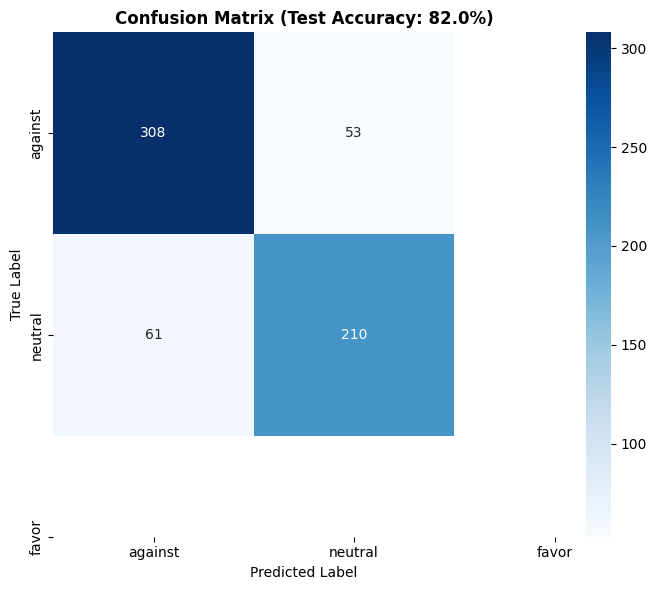

📊 Chart saved: confusion_matrix.png


In [16]:
# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(LABEL2ID.keys()),
            yticklabels=list(LABEL2ID.keys()))
ax.set_title(f'Confusion Matrix (Test Accuracy: {test_acc*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved: confusion_matrix.png')

## 💾 Step 10: Save Full Model for Inference

In [17]:
SAVE_DIR = 'roberta_stance_model'
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f'✅ Model saved to: {SAVE_DIR}/')
print(f'   roberta_stance_model/config.json')
print(f'   roberta_stance_model/model.safetensors')
print(f'   roberta_stance_model/tokenizer files')

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.92it/s]

✅ Model saved to: roberta_stance_model/
   roberta_stance_model/config.json
   roberta_stance_model/model.safetensors
   roberta_stance_model/tokenizer files


## 🔍 Step 11: Quick Inference Test

In [19]:
from transformers import RobertaForSequenceClassification, RobertaTokenizer
import torch

# Reload model fresh
infer_tokenizer = RobertaTokenizer.from_pretrained(SAVE_DIR)
infer_model     = RobertaForSequenceClassification.from_pretrained(SAVE_DIR)
infer_model     = infer_model.to(device)
infer_model.eval()

def predict_stance(text):
    inputs = infer_tokenizer(
        text,
        return_tensors  = 'pt',
        max_length      = 128,
        truncation      = True,
        padding         = 'max_length'
    ).to(device)

    with torch.no_grad():
        outputs = infer_model(**inputs)
        pred_id = outputs.logits.argmax(dim=1).item()
        confidence = torch.softmax(outputs.logits, dim=1).max().item()

    return ID2LABEL[pred_id], confidence

# Test sentences
test_sentences = [
    "Climate change is an existential threat and we must act now!",
    "Global warming is a hoax invented by scientists for grant money.",
    "Scientists are still debating the long-term effects of climate change.",
    "Vaccines have saved millions of lives and are completely safe.",
    "I don't trust the vaccine, too many unknown side effects.",
    "AI will create more jobs than it destroys in the long run.",
    "Artificial intelligence is an existential risk to humanity."
]

print('=== INFERENCE RESULTS ===\n')
for sentence in test_sentences:
    label, score = predict_stance(sentence)
    emoji = '✅' if label == 'favor' else '❌' if label == 'against' else '➖'
    print(f'{emoji} [{label.upper():8s}] ({score:.2f})  {sentence[:70]}')

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8424.23it/s]


=== INFERENCE RESULTS ===

✅ [FAVOR   ] (0.99)  Climate change is an existential threat and we must act now!
✅ [FAVOR   ] (0.73)  Global warming is a hoax invented by scientists for grant money.
✅ [FAVOR   ] (0.85)  Scientists are still debating the long-term effects of climate change.
❌ [AGAINST ] (0.53)  Vaccines have saved millions of lives and are completely safe.
❌ [AGAINST ] (0.89)  I don't trust the vaccine, too many unknown side effects.
❌ [AGAINST ] (0.71)  AI will create more jobs than it destroys in the long run.
✅ [FAVOR   ] (0.65)  Artificial intelligence is an existential risk to humanity.


---
## ✅ Summary

| Output | Description |
|---|---|
| `roberta_stance_model/` | Saved model ready for inference |
| `roberta_stance_best.pt` | Best checkpoint weights |
| `training_curves.png` | Loss / Accuracy / F1 over epochs |
| `confusion_matrix.png` | Per-class prediction breakdown |
| `split_distribution.png` | Train/Val/Test label balance |

### 🚀 Next Steps
1. ✅ ~~Data Collection~~
2. ✅ ~~Fine-tune RoBERTa~~
3. ⬅️ **Run inference on full dataset + track stance over time**
4. Build temporal analysis
5. Deploy Streamlit dashboard